# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [2]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

##### Data Visualization

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to visualize the distribution of ages
def plot_num_distribution(df, feature, bin_size=20):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[feature], bins=bin_size, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

c:\Users\witch\miniconda3\envs\ag\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


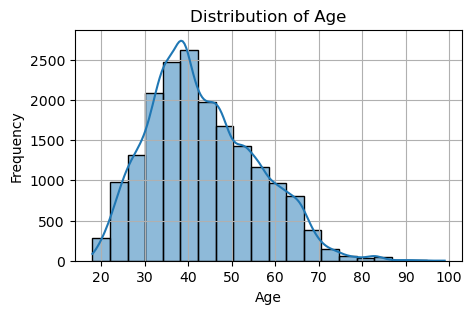

In [6]:
plot_num_distribution(df=df, feature='Age')

In [7]:
def plot_count_distribution(df, feature, rotation=0):
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=feature, palette='Set2')
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=rotation)
    plt.grid()
    plt.show()

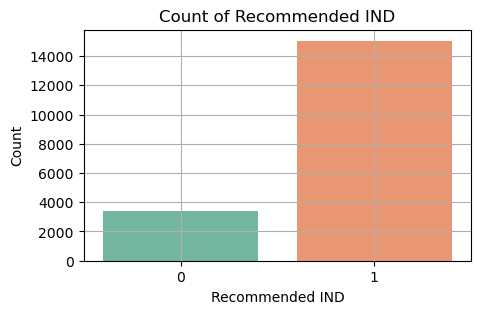

In [8]:
plot_count_distribution(df, 'Recommended IND')

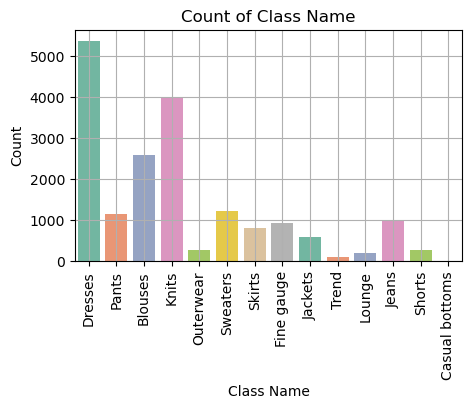

In [9]:
plot_count_distribution(df, 'Class Name', rotation=90)

In [10]:
def plot_reviews_by_cat(df, cat, top_count = 10):
    plt.figure(figsize=(8,3))
    division_counts = df[cat].value_counts().head(top_count)  # Top 10 divisions
    sns.barplot(x=division_counts.index, y=division_counts.values, palette='Set3')
    plt.title(f'Top {top_count} Divisions by Review Count')
    plt.xlabel(cat)
    plt.ylabel('Count of Reviews')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

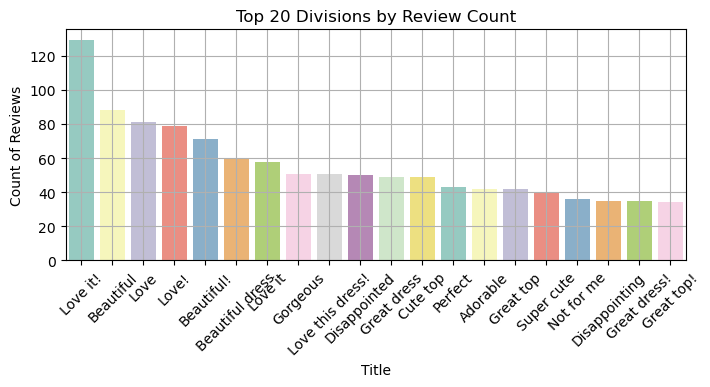

In [11]:
plot_reviews_by_cat(df, 'Title', top_count=20)

##### Split numerical, categorical, and text data

In [12]:
print(df.dtypes)

Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
Recommended IND             int64
dtype: object


In [13]:
from sklearn.pipeline import Pipeline

num_features = (
    X
    .select_dtypes(exclude=['object']).columns
    .drop(
        [
            'Clothing ID', # More of category than a numerical feature
        ],
    )
)
print('Numerical features:', num_features)

cat_features = (
    X[[
        'Clothing ID',
        'Title',
        'Division Name',
        'Department Name',
        'Class Name'
    ]].columns
)
print('Categorical features:', cat_features)


text_features = (
    X[[
        'Review Text',
    ]].columns
)
print ('Review Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='object')
Categorical features: Index(['Clothing ID', 'Title', 'Division Name', 'Department Name',
       'Class Name'],
      dtype='object')
Review Text features: Index(['Review Text'], dtype='object')


## Building Pipeline

#### Numerical feature pipeline

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'scaler',
        MinMaxScaler(),
    ),
])

num_pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())])

#### Categorical feature pipeline

In [15]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    (
        'ordinal_encoder',
        OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )
    ),    
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
        )
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
    ),
])

cat_pipeline

Pipeline(steps=[('ordinal_encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('cat_encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

#### Text feature pipeline

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
# Takes in a string for the character to count
# Outputs the number times that character appears in the text

class CountCharacter(BaseEstimator, TransformerMixin):
    def __init__(self, character: str):
        self.character = character

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [[text.count(self.character)] for text in X]

In [17]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
import numpy as np

initial_text_preprocess = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
])

# Create a pipeline for counting the number of spaces, `!`, and `?`
feature_engineering = FeatureUnion([
    ('count_spaces', CountCharacter(character=' ')),
    ('count_exclamations', CountCharacter(character='!')),
    ('count_question_marks', CountCharacter(character='?')),
])

character_counts_pipeline = Pipeline([
    (
        'initial_text_preprocess',
        initial_text_preprocess,
    ),
    (
        'feature_engineering',
        feature_engineering,
    ),
])
character_counts_pipeline

Pipeline(steps=[('initial_text_preprocess',
                 Pipeline(steps=[('dimension_reshaper',
                                  FunctionTransformer(func=<function reshape at 0x0000028BA7F7E6F0>,
                                                      kw_args={'newshape': -1}))])),
                ('feature_engineering',
                 FeatureUnion(transformer_list=[('count_spaces',
                                                 CountCharacter(character=' ')),
                                                ('count_exclamations',
                                                 CountCharacter(character='!')),
                                                ('count_question_marks',
                                                 CountCharacter(character='?'))]))])

#### Custom Transformer: spaCy, TF-IDF

In [18]:
# ! pip install spacy

In [19]:
! python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 640.0 kB/s eta 0:00:20
     ---------------------------------------- 0.1/12.8 MB 1.3 MB/s eta 0:00:10
     - -------------------------------------- 0.5/12.8 MB 4.0 MB/s eta 0:00:04
     --- ------------------------------------ 1.1/12.8 MB 7.1 MB/s eta 0:00:02
     ----- ---------------------------------- 1.9/12.8 MB 9.9 MB/s eta 0:00:02
     -------- ------------------------------- 2.6/12.8 MB 11.1 MB/s eta 0:00:01
     ---------- ----------------------------- 3.3/12.8 MB 12.4 MB/s eta 0:00:01
     ----------- ---------------------------- 3.8/12.8 MB 12.1 MB/s eta 0:00:01
     ----------- ---------------------------- 3.8/12.8 MB 12.1 MB/s eta 0:00:01
     ---------------- ----------------------- 5.2/12.8 MB 13.3 MB/s eta 0:00:01
     ------------------ --------------------- 5.9/12.8 MB 13.4 MB/s eta 0:00:01
     -------------------- ------------------- 6.5/12

In [20]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [21]:
class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized   

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
            max_features=5000,
            min_df=5,
            max_df=0.8
        ),
    ),
])
tfidf_pipeline 

Pipeline(steps=[('dimension_reshaper',
                 FunctionTransformer(func=<function reshape at 0x0000028BA7F7E6F0>,
                                     kw_args={'newshape': -1})),
                ('lemmatizer',
                 SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x0000028BB2B3DFC0>)),
                ('tfidf_vectorizer',
                 TfidfVectorizer(max_df=0.8, max_features=5000, min_df=5,
                                 stop_words='english'))])

#### Combine pipeline

In [23]:
from sklearn.compose import ColumnTransformer

feature_engineering = ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('character_counts', character_counts_pipeline, text_features),
        ('tfidf_text', tfidf_pipeline, text_features),
])

feature_engineering

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat_encoder',
                                                  OneHot...
                                 Pipeline(steps=[('dimension_reshaper',
                                                  FunctionTransformer(func=<function reshape at 0x0000028BA7F7E6F0>,
                                                                      kw_args={'newshape': -1})),
                                                 ('lemmatizer',
                                                  SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x0000028BB2B3DFC0>)),
                                                 ('tfidf_vectorizer',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=5000,
                                                                  min_df=5,
                                                                  stop_words='english'))]),
                                 Index(['Review Text'], dtype='object'))])

## Training Pipeline

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

model_pipeline = make_pipeline(
    feature_engineering,
    RandomForestClassifier(random_state=27),
)

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='m...
                                                                   FunctionTransformer(func=<function reshape at 0x0000028BA7F7E6F0>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('lemmatizer',
                                                                   SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x0000028BB2B3DFC0>)),
                                                                  ('tfidf_vectorizer',
                                                                   TfidfVectorizer(max_df=0.8,
                                                                                   max_features=5000,
                                                                                   min_df=5,
                                                                                   stop_words='english'))]),
                                                  Index(['Review Text'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=27))])

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_forest_pipeline = model_pipeline.predict(X_test)
accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)
precision_forest_pipeline = precision_score(y_test, y_pred_forest_pipeline, average='weighted')
recall_forest_pipeline = recall_score(y_test, y_pred_forest_pipeline, average='weighted')
f1_forest_pipeline = f1_score(y_test, y_pred_forest_pipeline, average='weighted')

print('Accuracy:', accuracy_forest_pipeline)
print('Precision:', precision_forest_pipeline)
print('Recall:', recall_forest_pipeline)
print('F1-Score:', f1_forest_pipeline)

# Get detailed classification report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_forest_pipeline))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_forest_pipeline))

# Calculate ROC-AUC for binary classification
try:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print('ROC-AUC:', roc_auc)
except:
    print("ROC-AUC couldn't be calculated.")

Accuracy: 0.8449864498644987
Precision: 0.8406293259129651
Recall: 0.8449864498644987
F1-Score: 0.799340752141943

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.16      0.27       327
           1       0.85      0.99      0.91      1518

    accuracy                           0.84      1845
   macro avg       0.83      0.58      0.59      1845
weighted avg       0.84      0.84      0.80      1845

Confusion Matrix:
[[  53  274]
 [  12 1506]]
ROC-AUC: 0.8991258818741866


## Fine-Tuning Pipeline

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit

my_distributions = dict(
    randomforestclassifier__max_features=[
        100,
        150,
        200
    ],
    randomforestclassifier__n_estimators=[
        100,
        150,
        200
    ],
)

param_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=my_distributions,
    n_iter=6,     # Try 6 different combinations of parameters
    cv=ShuffleSplit(n_splits=1, test_size=0.2, random_state=27),  # One train/val split
    n_jobs=-1,    # Use all available processors (for multiprocessing)
    refit=True,   # Refit the model using the best parameters found
    verbose=3,    # Output of parameters, score, time
    random_state=27,
)

param_search.fit(X_train, y_train)

# Retrieve the best parameters
param_search.best_params_

Fitting 1 folds for each of 6 candidates, totalling 6 fits


{'randomforestclassifier__n_estimators': 100,
 'randomforestclassifier__max_features': 200}

In [27]:
model_best = param_search.best_estimator_
model_best

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='m...
                                                                   FunctionTransformer(func=<function reshape at 0x0000028BA7F7E6F0>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('lemmatizer',
                                                                   SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x0000028BC91077C0>)),
                                                                  ('tfidf_vectorizer',
                                                                   TfidfVectorizer(max_df=0.8,
                                                                                   max_features=5000,
                                                                                   min_df=5,
                                                                                   stop_words='english'))]),
                                                  Index(['Review Text'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_features=200, random_state=27))])

In [28]:
y_pred_forest_pipeline = model_best.predict(X_test)

accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)
precision_forest_pipeline = precision_score(y_test, y_pred_forest_pipeline, average='weighted')
recall_forest_pipeline = recall_score(y_test, y_pred_forest_pipeline, average='weighted')
f1_forest_pipeline = f1_score(y_test, y_pred_forest_pipeline, average='weighted')

print('Accuracy:', accuracy_forest_pipeline)
print('Precision:', precision_forest_pipeline)
print('Recall:', recall_forest_pipeline)
print('F1-Score:', f1_forest_pipeline)

# Get detailed classification report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_forest_pipeline))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_forest_pipeline))

# Calculate ROC-AUC for binary classification
try:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print('ROC-AUC:', roc_auc)
except:
    print("ROC-AUC couldn't be calculated.")

Accuracy: 0.8498644986449865
Precision: 0.8380506340440763
Recall: 0.8498644986449865
F1-Score: 0.8141778739945147

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.22      0.35       327
           1       0.85      0.98      0.92      1518

    accuracy                           0.85      1845
   macro avg       0.81      0.60      0.63      1845
weighted avg       0.84      0.85      0.81      1845

Confusion Matrix:
[[  73  254]
 [  23 1495]]
ROC-AUC: 0.8991258818741866
